# HR Analytics – Dự đoán nghỉ việc (Attrition)
Notebook này xây dựng pipeline mô hình hóa với các cải tiến: đánh giá bằng **Stratified CV**, chọn metric phù hợp với dữ liệu mất cân bằng (**ROC-AUC, PR-AUC, Recall/F1**), feature engineering, so sánh nhiều mô hình, tinh chỉnh siêu tham số và chọn **ngưỡng quyết định**.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (StratifiedKFold, cross_validate, cross_val_predict,
                                     train_test_split, RandomizedSearchCV)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (roc_auc_score, average_precision_score, precision_recall_curve,
                             classification_report, confusion_matrix, ConfusionMatrixDisplay)
from xgboost import XGBClassifier

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")
print("Đã kết nối Python thành công!")

Đã kết nối Python thành công!


## 1. Đọc dữ liệu & làm sạch

In [2]:
DATA_PATH = "../data/WA_Fn-UseC_-HR-Employee-Attrition.csv"
df = pd.read_csv(DATA_PATH)
print(df.shape)
print(df["Attrition"].value_counts(normalize=True).round(3))

emp_id = df["EmployeeNumber"].copy()  # giữ lại mã nhân viên để lập danh sách rủi ro

# Cột hằng số (không mang thông tin) và cột ID
drop_cols = [c for c in df.columns if df[c].nunique() == 1] + ["EmployeeNumber"]
print("Bỏ các cột:", drop_cols)
df = df.drop(columns=drop_cols)

(1470, 35)
Attrition
No     0.839
Yes    0.161
Name: proportion, dtype: float64
Bỏ các cột: ['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber']


## 2. Phân tích khám phá dữ liệu (EDA)
So sánh nhóm **nghỉ việc (Yes)** và **ở lại (No)** để tìm các điểm khác biệt.

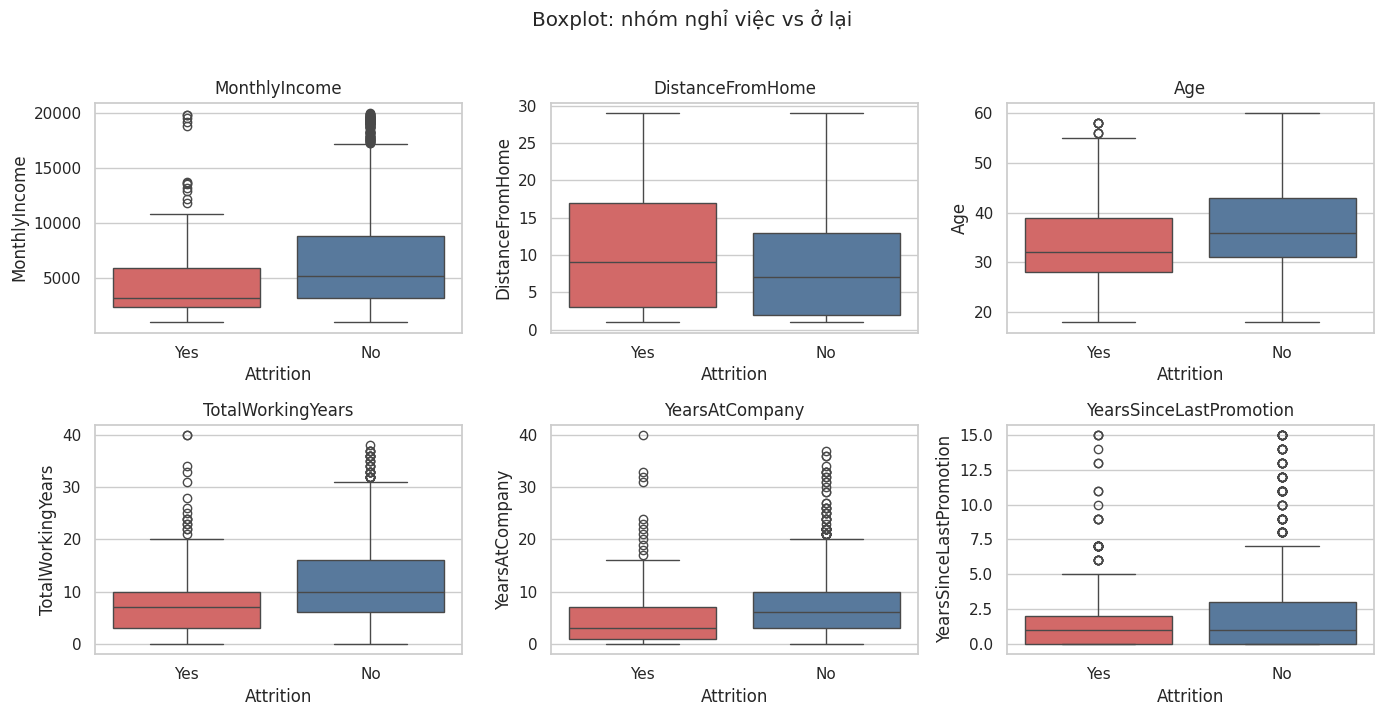

Attrition                    No     Yes
MonthlyIncome            5204.0  3202.0
DistanceFromHome            7.0     9.0
Age                        36.0    32.0
TotalWorkingYears          10.0     7.0
YearsAtCompany              6.0     3.0
YearsSinceLastPromotion     1.0     1.0


In [3]:
raw = pd.read_csv(DATA_PATH)
palette = {"No": "#4C78A8", "Yes": "#E45756"}

# 2.1 Boxplot các biến số: lương, khoảng cách, tuổi, kinh nghiệm...
num_eda = ["MonthlyIncome", "DistanceFromHome", "Age", "TotalWorkingYears",
           "YearsAtCompany", "YearsSinceLastPromotion"]
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.ravel(), num_eda):
    sns.boxplot(data=raw, x="Attrition", y=col, hue="Attrition", palette=palette, legend=False, ax=ax)
    ax.set_title(col)
plt.suptitle("Boxplot: nhóm nghỉ việc vs ở lại", y=1.02); plt.tight_layout(); plt.show()

print(raw.groupby("Attrition")[num_eda].median().T.round(1))

**Nhận xét (trung vị nhóm nghỉ việc so với ở lại):** `MonthlyIncome` 3,202 so với 5,204; `Age` 32 so với 36; `TotalWorkingYears` 7 so với 10; `YearsAtCompany` 3 so với 6; `DistanceFromHome` 9 so với 7 km. Riêng `YearsSinceLastPromotion` giống nhau ở cả hai nhóm (trung vị 1 năm), nên biến này không phân biệt được hai nhóm.

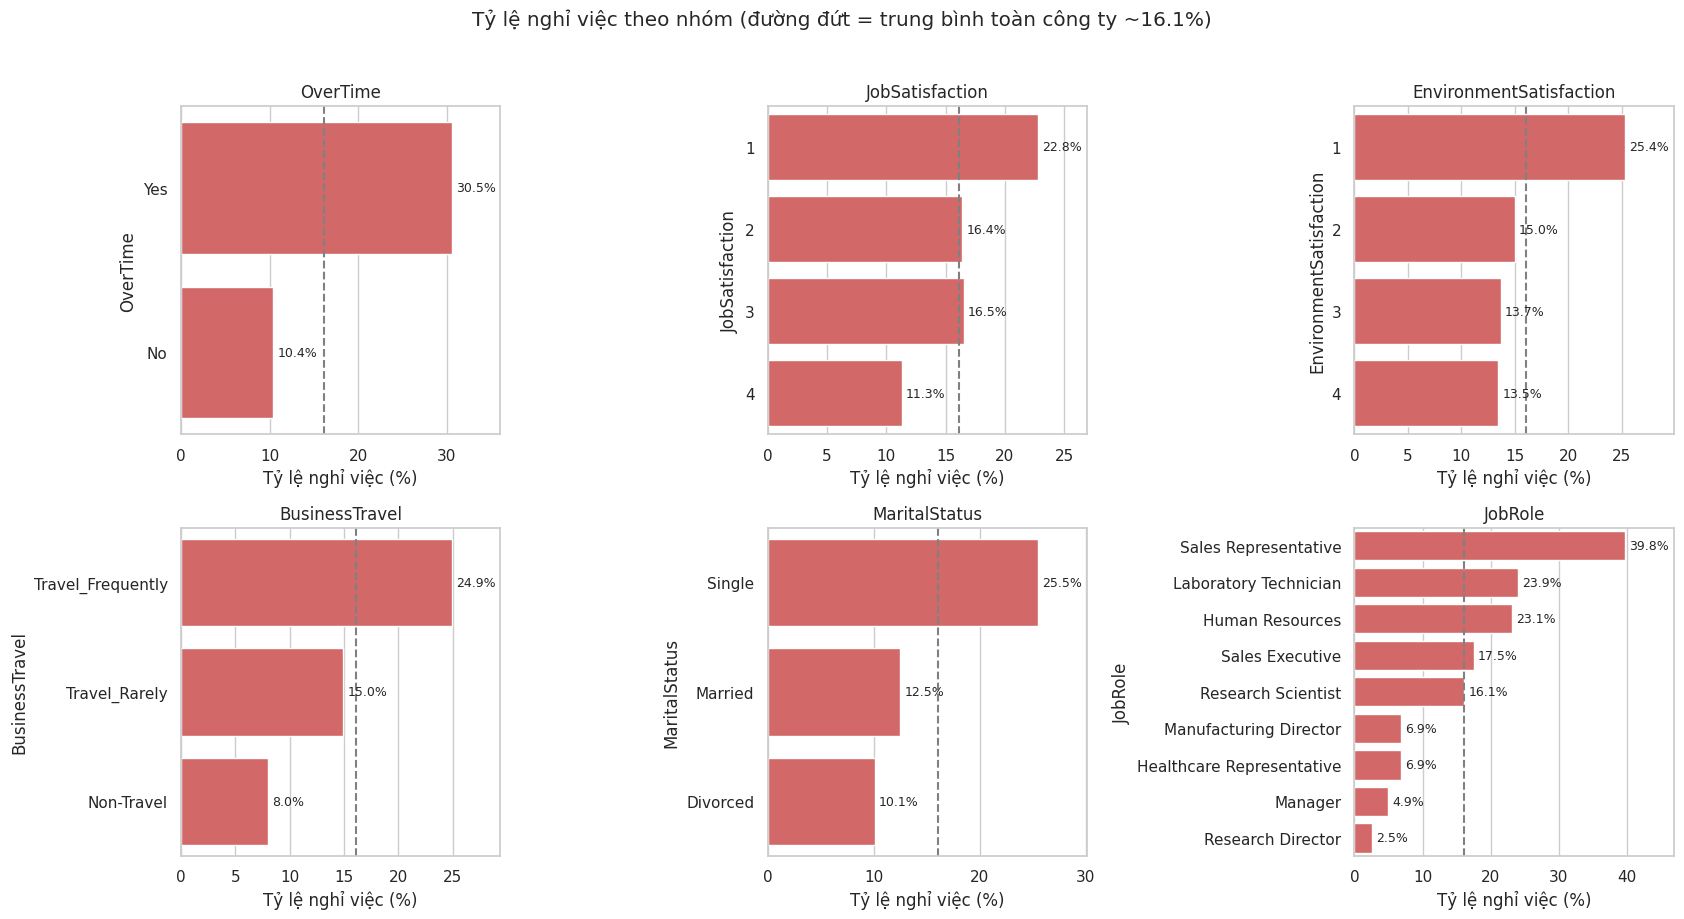

In [4]:
# 2.2 Bar chart: tỷ lệ nghỉ việc theo các biến phân loại / thứ hạng
cat_eda = ["OverTime", "JobSatisfaction", "EnvironmentSatisfaction",
           "BusinessTravel", "MaritalStatus", "JobRole"]
ordinal = {"JobSatisfaction", "EnvironmentSatisfaction"}   # giữ thứ tự tự nhiên 1 -> 4
fig, axes = plt.subplots(2, 3, figsize=(17, 9))
for ax, col in zip(axes.ravel(), cat_eda):
    rate = raw.assign(left=(raw["Attrition"] == "Yes")).groupby(col)["left"].mean() * 100
    rate = rate.sort_index() if col in ordinal else rate.sort_values(ascending=False)
    sns.barplot(x=rate.values, y=rate.index.astype(str), color="#E45756", ax=ax)
    for bar, v in zip(ax.patches, rate.values):
        ax.annotate(f"{v:.1f}%", (bar.get_width(), bar.get_y() + bar.get_height() / 2),
                    ha="left", va="center", fontsize=9, xytext=(3, 0), textcoords="offset points")
    ax.axvline(16.1, ls="--", c="gray"); ax.set_xlabel("Tỷ lệ nghỉ việc (%)"); ax.set_title(col)
    ax.set_xlim(0, rate.max() * 1.18)
plt.suptitle("Tỷ lệ nghỉ việc theo nhóm (đường đứt = trung bình toàn công ty ~16.1%)", y=1.02)
plt.tight_layout(); plt.show()

**Nhận xét:** (1) `JobSatisfaction` = 1 nghỉ việc 22.8% so với 11.3% ở mức 4; `EnvironmentSatisfaction` = 1 là 25.4% so với 13.5% ở mức 4. (2) `Travel_Frequently` nghỉ việc 24.9% so với 8.0% ở `Non-Travel`. (3) Nhân viên độc thân (Single) 25.5% so với 10.1% (Divorced) và 12.5% (Married). (4) `Sales Representative` cao nhất với 39.8%, trong khi `Research Director` và `Manager` thấp nhất. Mức hài lòng cho thấy xu hướng giảm dần nhưng không hoàn toàn đơn điệu (mức 2 và 3 gần như bằng nhau).

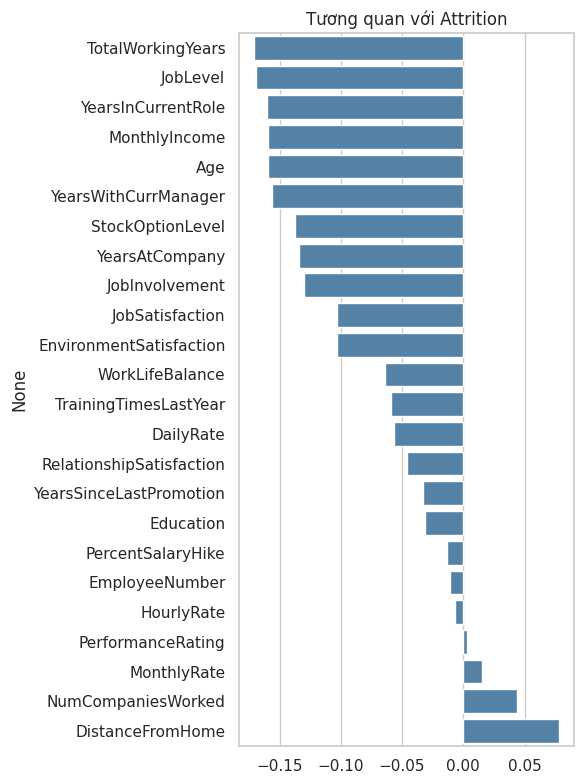

In [5]:
# 2.3 Tương quan giữa các biến số và Attrition
corr = raw.assign(Attrition=(raw["Attrition"] == "Yes").astype(int)).select_dtypes("number").corr()["Attrition"]
corr = corr.drop("Attrition").dropna().sort_values()
plt.figure(figsize=(6, 8)); sns.barplot(x=corr.values, y=corr.index, color="steelblue")
plt.title("Tương quan với Attrition"); plt.tight_layout(); plt.show()

**Nhận xét:** các biến tương quan âm nhất với `Attrition` là `TotalWorkingYears`, `JobLevel`, `YearsInCurrentRole`, `MonthlyIncome` và `Age` (khoảng −0.16 đến −0.17): nhân viên trẻ, ít kinh nghiệm, cấp thấp, lương thấp dễ nghỉ việc hơn. Các hệ số đều nhỏ (|r| < 0.2) nên không biến đơn lẻ nào giải thích được nhiều; `DistanceFromHome` là biến duy nhất tương quan dương đáng kể (+0.08).

                        attrition_rate  employee_count
Department                                            
Sales                            0.206             446
Human Resources                  0.190              63
Research & Development           0.138             961


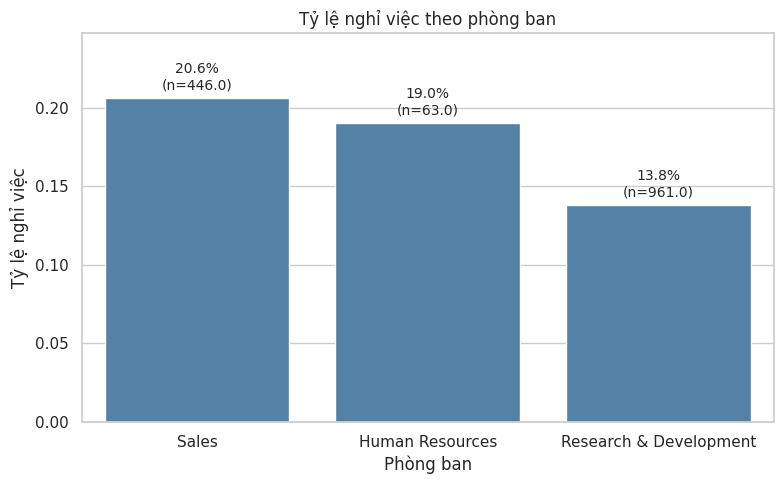

In [6]:
# 2.4 Tỷ lệ nghỉ việc theo phòng ban
dept = (raw.assign(left=(raw["Attrition"] == "Yes").astype(int))
           .groupby("Department").agg(attrition_rate=("left", "mean"), employee_count=("left", "size"))
           .sort_values("attrition_rate", ascending=False))
print(dept.round(3))

plt.figure(figsize=(8, 5))
ax = sns.barplot(data=dept.reset_index(), x="Department", y="attrition_rate", color="steelblue")
for bar, (_, row) in zip(ax.patches, dept.iterrows()):
    ax.annotate(f"{row['attrition_rate']:.1%}\n(n={row['employee_count']})",
                (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                ha="center", va="bottom", fontsize=10, xytext=(0, 4), textcoords="offset points")
ax.set(title="Tỷ lệ nghỉ việc theo phòng ban", xlabel="Phòng ban", ylabel="Tỷ lệ nghỉ việc")
ax.set_ylim(0, dept["attrition_rate"].max() * 1.2)
plt.tight_layout(); plt.show()

**Nhận xét:** Sales có tỷ lệ nghỉ việc cao nhất (20.6%), tiếp theo là Human Resources (19.0%), còn Research & Development thấp nhất (13.8%). Nhóm HR chỉ có 63 người nên tỷ lệ này kém ổn định, không nên diễn giải quá mức.

OverTime  employee_count  attrition_count  attrition_rate
     Yes             416              127        0.305288
      No            1054              110        0.104364


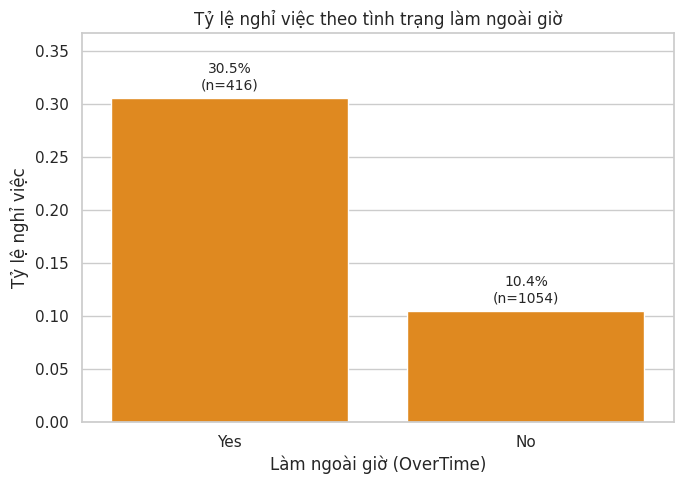

In [7]:
# 2.5 Tỷ lệ nghỉ việc theo OverTime (kèm số lượng)
ot = (raw.assign(left=(raw["Attrition"] == "Yes").astype(int))
         .groupby("OverTime").agg(employee_count=("left", "size"), attrition_count=("left", "sum"),
                                  attrition_rate=("left", "mean"))
         .reindex(["Yes", "No"]).reset_index())
print(ot.to_string(index=False))

plt.figure(figsize=(7, 5))
ax = sns.barplot(data=ot, x="OverTime", y="attrition_rate", color="darkorange")
for bar, (_, row) in zip(ax.patches, ot.iterrows()):
    ax.annotate(f"{row['attrition_rate']:.1%}\n(n={row['employee_count']})",
                (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                ha="center", va="bottom", fontsize=10, xytext=(0, 4), textcoords="offset points")
ax.set(title="Tỷ lệ nghỉ việc theo tình trạng làm ngoài giờ", xlabel="Làm ngoài giờ (OverTime)", ylabel="Tỷ lệ nghỉ việc")
ax.set_ylim(0, ot["attrition_rate"].max() * 1.2)
plt.tight_layout(); plt.show()

**Nhận xét:** nhân viên làm thêm giờ nghỉ việc **30.5%** (127/416) so với **10.4%** (110/1,054) ở nhóm không làm thêm giờ, gấp khoảng 3 lần. Đây là chênh lệch lớn nhất trong các biến phân loại và cũng là đặc trưng quan trọng nhất của mô hình (Mục 8).

## 3. Feature engineering
Các biến phái sinh phản ánh mức lương so với cấp bậc, mức độ gắn bó và tình trạng thăng tiến.

In [8]:
df["IncomePerLevel"]     = df["MonthlyIncome"] / df["JobLevel"]
df["LoyaltyRatio"]       = df["YearsAtCompany"] / (df["TotalWorkingYears"] + 1)
df["PromoGapRatio"]      = df["YearsSinceLastPromotion"] / (df["YearsAtCompany"] + 1)
df["AvgSatisfaction"]    = df[["JobSatisfaction", "EnvironmentSatisfaction",
                               "RelationshipSatisfaction", "WorkLifeBalance"]].mean(axis=1)
df["OT_LowSatisfaction"] = ((df["OverTime"] == "Yes") & (df["JobSatisfaction"] <= 2)).astype(int)
df["JobHopper"]          = df["NumCompaniesWorked"] / (df["TotalWorkingYears"] + 1)

y = (df.pop("Attrition") == "Yes").astype(int)
X = df

# BusinessTravel có thứ tự tự nhiên -> ordinal; các biến chữ còn lại -> one-hot
ord_cols = ["BusinessTravel"]
travel_order = [["Non-Travel", "Travel_Rarely", "Travel_Frequently"]]
cat_cols = [c for c in X.select_dtypes(exclude="number").columns if c not in ord_cols]
num_cols = [c for c in X.columns if c not in cat_cols + ord_cols]

def make_preprocessor(scale=True):
    return ColumnTransformer([
        ("num", StandardScaler() if scale else "passthrough", num_cols),
        ("ord", OrdinalEncoder(categories=travel_order), ord_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ])

## 4. Chia train/test & so sánh mô hình bằng Stratified CV
**Lưu ý:** với ~84% nhãn `No`, mô hình đoán "No" cho tất cả đã đạt ~84% accuracy, nên ta so sánh bằng ROC-AUC, PR-AUC, Recall và F1 của lớp `Yes`.
Test set được giữ riêng, chỉ dùng một lần ở cuối.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

models = {
    "LogReg": Pipeline([("pre", make_preprocessor(True)),
                        ("m", LogisticRegression(C=0.1, class_weight="balanced", max_iter=3000))]),
    "RandomForest": Pipeline([("pre", make_preprocessor(False)),
                              ("m", RandomForestClassifier(n_estimators=500, max_depth=8,
                                    min_samples_leaf=5, class_weight="balanced",
                                    random_state=RANDOM_STATE, n_jobs=-1))]),
    "XGBoost": Pipeline([("pre", make_preprocessor(False)),
                         ("m", XGBClassifier(n_estimators=300, max_depth=3, learning_rate=0.05,
                                subsample=0.8, colsample_bytree=0.8, scale_pos_weight=pos_weight,
                                eval_metric="logloss", random_state=RANDOM_STATE, n_jobs=-1))]),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = ["roc_auc", "average_precision", "recall", "f1"]

rows = []
for name, pipe in models.items():
    res = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=1)
    rows.append({"model": name, **{s: res[f"test_{s}"].mean() for s in scoring},
                 "roc_auc_std": res["test_roc_auc"].std()})
cv_table = pd.DataFrame(rows).set_index("model").round(3)
cv_table

,roc_auc,average_precision,recall,f1,roc_auc_std
model,,,,,
LogReg,0.829,0.621,0.737,0.495,0.030
RandomForest,0.810,0.569,0.384,0.460,0.026
XGBoost,0.812,0.593,0.511,0.526,0.021


## 5. Tinh chỉnh siêu tham số (RandomizedSearchCV, tối ưu ROC-AUC)

In [10]:
param_dists = {
    "LogReg": {"m__C": np.logspace(-3, 1, 20)},
    "RandomForest": {"m__n_estimators": [300, 500, 800],
                     "m__max_depth": [4, 6, 8, 12, None],
                     "m__min_samples_leaf": [2, 5, 10, 20],
                     "m__max_features": ["sqrt", 0.3, 0.5]},
    "XGBoost": {"m__n_estimators": [150, 300, 500],
                "m__max_depth": [2, 3, 4, 5],
                "m__learning_rate": [0.01, 0.03, 0.05, 0.1],
                "m__subsample": [0.6, 0.8, 1.0],
                "m__colsample_bytree": [0.6, 0.8, 1.0],
                "m__min_child_weight": [1, 3, 5],
                "m__reg_lambda": [1, 5, 10]},
}

best = {}
for name, pipe in models.items():
    search = RandomizedSearchCV(pipe, param_dists[name], n_iter=15, scoring="roc_auc",
                                cv=cv, random_state=RANDOM_STATE, n_jobs=-1, refit=True)
    search.fit(X_train, y_train)
    best[name] = search
    print(f"{name:13s} CV ROC-AUC = {search.best_score_:.3f}  | {search.best_params_}")

LogReg        CV ROC-AUC = 0.830  | {'m__C': np.float64(0.07847599703514611)}


RandomForest  CV ROC-AUC = 0.813  | {'m__n_estimators': 800, 'm__min_samples_leaf': 5, 'm__max_features': 'sqrt', 'm__max_depth': 12}


XGBoost       CV ROC-AUC = 0.831  | {'m__subsample': 0.6, 'm__reg_lambda': 10, 'm__n_estimators': 300, 'm__min_child_weight': 3, 'm__max_depth': 3, 'm__learning_rate': 0.1, 'm__colsample_bytree': 0.6}


## 6. Chọn ngưỡng quyết định
Ngưỡng 0.5 mặc định hiếm khi phù hợp với dữ liệu mất cân bằng. Ta lấy xác suất out-of-fold trên tập train rồi chọn ngưỡng theo mục tiêu của HR (ở đây: **Recall ≥ 70%** với precision cao nhất có thể). Có thể chỉnh `TARGET_RECALL`.

Mô hình tốt nhất: XGBoost


Ngưỡng chọn = 0.295 | OOF precision = 0.428, recall = 0.700


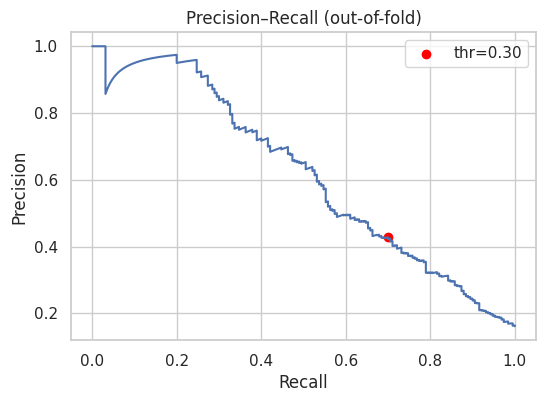

In [11]:
best_name = max(best, key=lambda k: best[k].best_score_)
best_model = best[best_name].best_estimator_
print("Mô hình tốt nhất:", best_name)

oof_proba = cross_val_predict(best_model, X_train, y_train, cv=cv, method="predict_proba")[:, 1]
prec, rec, thr = precision_recall_curve(y_train, oof_proba)

TARGET_RECALL = 0.70
ok = np.where(rec[:-1] >= TARGET_RECALL)[0]
idx = ok[np.argmax(prec[:-1][ok])] if len(ok) else np.argmax(2*prec[:-1]*rec[:-1]/(prec[:-1]+rec[:-1]+1e-9))
threshold = thr[idx]
print(f"Ngưỡng chọn = {threshold:.3f} | OOF precision = {prec[idx]:.3f}, recall = {rec[idx]:.3f}")

plt.figure(figsize=(6, 4))
plt.plot(rec, prec); plt.scatter(rec[idx], prec[idx], c="red", label=f"thr={threshold:.2f}")
plt.xlabel("Recall"); plt.ylabel("Precision"); plt.title("Precision–Recall (out-of-fold)")
plt.legend(); plt.show()

## 7. Đánh giá cuối cùng trên tập test (chạm test set một lần)

ROC-AUC : 0.779
PR-AUC  : 0.476  (baseline = 0.160)
              precision    recall  f1-score   support

          No       0.92      0.80      0.85       247
         Yes       0.38      0.64      0.47        47

    accuracy                           0.77       294
   macro avg       0.65      0.72      0.66       294
weighted avg       0.83      0.77      0.79       294



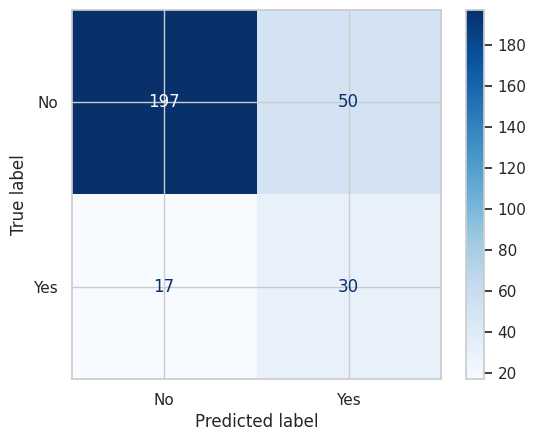

In [12]:
proba_test = best_model.predict_proba(X_test)[:, 1]
pred_test = (proba_test >= threshold).astype(int)

print(f"ROC-AUC : {roc_auc_score(y_test, proba_test):.3f}")
print(f"PR-AUC  : {average_precision_score(y_test, proba_test):.3f}  (baseline = {y_test.mean():.3f})")
print(classification_report(y_test, pred_test, target_names=["No", "Yes"]))
ConfusionMatrixDisplay(confusion_matrix(y_test, pred_test), display_labels=["No", "Yes"]).plot(cmap="Blues")
plt.show()

## 8. Độ quan trọng đặc trưng (Permutation Importance)
Impurity importance của Random Forest thiên lệch về biến số liên tục có nhiều giá trị (ví dụ `MonthlyIncome`). Permutation importance trên tập test đáng tin cậy hơn để đưa vào báo cáo.

                feature   mean    std
               OverTime 0.1065 0.0172
       StockOptionLevel 0.0289 0.0079
          MonthlyIncome 0.0159 0.0107
        AvgSatisfaction 0.0159 0.0096
         BusinessTravel 0.0129 0.0061
          MaritalStatus 0.0111 0.0044
                    Age 0.0097 0.0066
        JobSatisfaction 0.0090 0.0032
   YearsWithCurrManager 0.0077 0.0059
EnvironmentSatisfaction 0.0070 0.0046
         JobInvolvement 0.0067 0.0044
                 Gender 0.0066 0.0037
  TrainingTimesLastYear 0.0065 0.0025
YearsSinceLastPromotion 0.0062 0.0033
               JobLevel 0.0058 0.0030

Hạng của DailyRate: 34 / 36 | mean = -0.0063


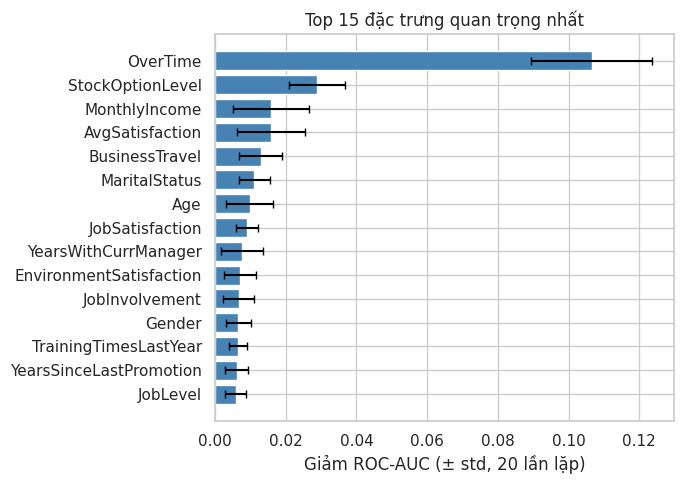

In [13]:
perm = permutation_importance(best_model, X_test, y_test, scoring="roc_auc",
                              n_repeats=20, random_state=RANDOM_STATE, n_jobs=-1)
imp_all = (pd.DataFrame({"feature": X_test.columns, "mean": perm.importances_mean, "std": perm.importances_std})
             .sort_values("mean", ascending=False).reset_index(drop=True))
imp = imp_all.head(15)
print(imp.round(4).to_string(index=False))
print("\nHạng của DailyRate:", int(imp_all.index[imp_all.feature == "DailyRate"][0]) + 1, "/", len(imp_all),
      "| mean =", imp_all.loc[imp_all.feature == "DailyRate", "mean"].round(4).values[0])

plt.figure(figsize=(7, 5))
top = imp.iloc[::-1]   # barh vẽ từ dưới lên nên đảo thứ tự
plt.barh(top["feature"], top["mean"], xerr=top["std"], color="steelblue", ecolor="black", capsize=3)
plt.xlabel("Giảm ROC-AUC (± std, 20 lần lặp)")
plt.title("Top 15 đặc trưng quan trọng nhất")
plt.tight_layout(); plt.show()

## 9. Feature Importance – Decision Tree (max_depth=5)
Decision Tree với chiều sâu giới hạn (max_depth=5) là mô hình đơn giản, dễ diễn giải. Huấn luyện trên **toàn bộ 1,470 bản ghi** nên đây là độ quan trọng *in-sample* dựa trên impurity của một cây đơn: thiên về biến liên tục/có nhiều giá trị và chưa kiểm chứng trên dữ liệu chưa thấy. Chỉ dùng để minh họa; kết luận chính dựa trên Permutation Importance (Mục 8).


=== TOP 10 FEATURE IMPORTANCE (Decision Tree, max_depth=5, toàn bộ 1.470 bản ghi) ===
                feature  importance  importance_pct
           OverTime_Yes    0.217081         21.7081
              JobHopper    0.144839         14.4839
               JobLevel    0.095122          9.5122
JobRole_Sales Executive    0.064335          6.4335
      TotalWorkingYears    0.057288          5.7288
                    Age    0.051930          5.1930
     NumCompaniesWorked    0.044558          4.4558
        WorkLifeBalance    0.038473          3.8473
              DailyRate    0.034425          3.4425
   MaritalStatus_Single    0.027804          2.7804


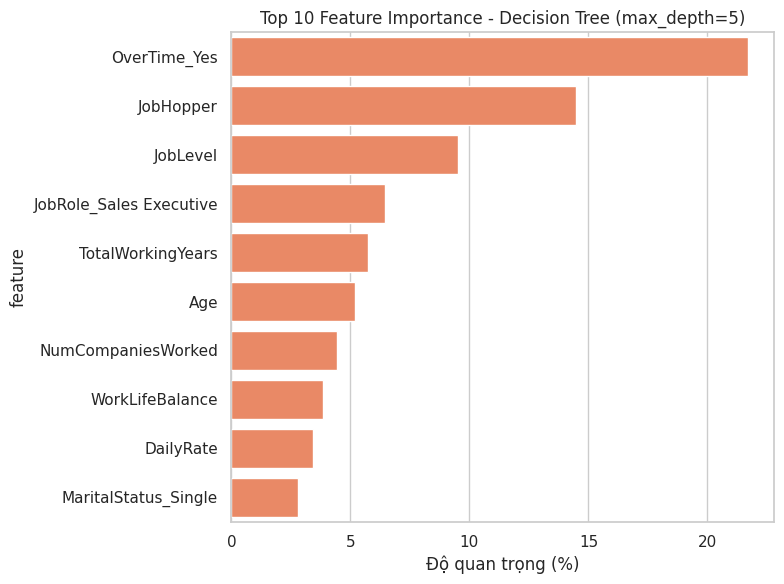


=== CHI TIẾT TOP 5 ĐẶC TRƯNG ===
OverTime_Yes        : 21.7081%
JobHopper           : 14.4839%
JobLevel            :  9.5122%
JobRole_Sales Executive:  6.4335%
TotalWorkingYears   :  5.7288%


In [14]:
# Huấn luyện Decision Tree với max_depth=5 trên toàn bộ dataset
dt_pipeline = Pipeline([
    ("pre", make_preprocessor(False)),
    ("m", DecisionTreeClassifier(max_depth=5, class_weight="balanced", random_state=RANDOM_STATE))
])
dt_pipeline.fit(X, y)

# Lấy feature importance từ Decision Tree
preprocessor = dt_pipeline.named_steps["pre"]
dt_model = dt_pipeline.named_steps["m"]

# Lấy tên các đặc trưng sau khi transform
feature_names = []
num_features = preprocessor.named_transformers_["num"].get_feature_names_out(num_cols).tolist()
ord_features = preprocessor.named_transformers_["ord"].get_feature_names_out(ord_cols).tolist()
cat_features = preprocessor.named_transformers_["cat"].get_feature_names_out(cat_cols).tolist()

feature_names = num_features + ord_features + cat_features

# Tính toán feature importance (normalized)
importances = dt_model.feature_importances_
dt_imp = pd.DataFrame({
    "feature": feature_names,
    "importance": importances,
    "importance_pct": (importances * 100).round(4)
}).sort_values("importance", ascending=False)

print("\n=== TOP 10 FEATURE IMPORTANCE (Decision Tree, max_depth=5, toàn bộ 1.470 bản ghi) ===")
print(dt_imp.head(10).to_string(index=False))

# Vẽ biểu đồ
plt.figure(figsize=(8, 6))
sns.barplot(data=dt_imp.head(10), x="importance_pct", y="feature", color="coral")
plt.xlabel("Độ quan trọng (%)"); plt.title("Top 10 Feature Importance - Decision Tree (max_depth=5)")
plt.tight_layout(); plt.show()

# Chi tiết cho top 5
print("\n=== CHI TIẾT TOP 5 ĐẶC TRƯNG ===")
for _, row in dt_imp.head(5).iterrows():
    print(f"{row['feature']:20s}: {row['importance_pct']:7.4f}%")

## 10. Danh sách nhân sự có nguy cơ nghỉ việc cao
Dùng xác suất **out-of-fold** trên toàn bộ nhân viên (mỗi người được chấm điểm bởi mô hình không được huấn luyện trên chính người đó), rồi xếp hạng theo nguy cơ.

In [15]:
risk = cross_val_predict(best_model, X, y, cv=cv, method="predict_proba")[:, 1]
risk_df = (pd.DataFrame({"EmployeeNumber": emp_id, "RiskScore": risk.round(3),
                         "Flagged": risk >= threshold, "ActualLeft": y,
                         "JobRole": X["JobRole"], "OverTime": X["OverTime"],
                         "MonthlyIncome": X["MonthlyIncome"], "JobSatisfaction": X["JobSatisfaction"]})
             .sort_values("RiskScore", ascending=False))
print(f"Số nhân viên bị gắn cờ nguy cơ: {int(risk_df.Flagged.sum())} / {len(risk_df)}")
risk_df.head(15)

Số nhân viên bị gắn cờ nguy cơ: 430 / 1470


,EmployeeNumber,RiskScore,Flagged,ActualLeft,JobRole,OverTime,MonthlyIncome,JobSatisfaction
463,622,0.997,True,1,Laboratory Technician,Yes,2340,4
1060,1494,0.997,True,1,Laboratory Technician,Yes,3172,1
1365,1928,0.995,True,1,Sales Representative,No,1091,1
1339,1878,0.993,True,1,Research Scientist,Yes,2472,2
688,959,0.992,True,1,Sales Representative,Yes,2121,2
911,1273,0.991,True,1,Sales Representative,Yes,1118,4
798,1108,0.990,True,1,Research Scientist,Yes,2313,2
457,614,0.989,True,1,Sales Representative,Yes,1878,2
1436,2021,0.988,True,0,Sales Representative,Yes,2380,1
731,1016,0.985,True,1,Research Scientist,Yes,2600,1


In [16]:
# Nhóm bị gắn cờ khác gì so với phần còn lại? -> cơ sở cho chính sách giữ chân
flag = X.assign(Flagged=risk >= threshold)
print(flag.groupby("Flagged")[["MonthlyIncome", "DistanceFromHome", "AvgSatisfaction",
                                "YearsSinceLastPromotion", "OT_LowSatisfaction"]].mean().round(2).T)
print("\nTỷ lệ làm thêm giờ:", flag.groupby("Flagged")["OverTime"].apply(lambda s: (s == "Yes").mean()).round(2).to_dict())

Flagged                    False    True 
MonthlyIncome            7323.65  4517.95
DistanceFromHome            8.87     9.98
AvgSatisfaction             2.79     2.59
YearsSinceLastPromotion     2.32     1.86
OT_LowSatisfaction          0.06     0.21

Tỷ lệ làm thêm giờ: {False: 0.19, True: 0.52}


## 11. Đề xuất chính sách giữ chân nhân sự
Các con số dưới đây lấy từ EDA (Mục 2), permutation importance (Mục 8) và nhóm bị gắn cờ (Mục 10); tỷ lệ nghỉ việc trung bình toàn công ty là **16.1%**.

| Phát hiện (số liệu) | Chính sách đề xuất |
|---|---|
| **Làm thêm giờ**: nghỉ việc 30.5% (OT) so với 10.4% (không OT), gấp ~3 lần; là đặc trưng quan trọng nhất (giảm AUC ≈ 0.106). Trong nhóm bị gắn cờ, 52% làm thêm giờ so với 19% ở nhóm còn lại | Giới hạn số giờ OT, phân bổ lại khối lượng công việc, theo dõi ưu tiên nhóm bị gắn cờ |
| **Thu nhập thấp**: dưới $3,000/tháng nghỉ việc 28.6% so với 11.5% từ $3,000 trở lên; nhóm này chiếm 47.7% số người nghỉ việc. `MonthlyIncome` nằm trong top 5 | Rà soát lương sàn cho vị trí thu nhập thấp, gắn tăng lương với đánh giá hiệu suất |
| **Không có quyền chọn cổ phiếu**: `StockOptionLevel` = 0 nghỉ việc 24.4% so với 7.6–9.4% ở mức 1–2; đứng thứ 2 về độ quan trọng | Mở rộng stock option / thưởng dài hạn cho nhân viên cấp thấp |
| **Hài lòng thấp**: `JobSatisfaction` = 1 nghỉ việc 22.8% (mức 4: 11.3%); `EnvironmentSatisfaction` = 1: 25.4%; `WorkLifeBalance` = 1: 31.2% | Khảo sát định kỳ, họp 1-1 với quản lý cho nhân viên có điểm 1–2; nhóm OT + hài lòng ≤ 2 nghỉ việc 36.6% (153 người) nên được ưu tiên |
| **Đi công tác thường xuyên**: `Travel_Frequently` 24.9% so với `Non-Travel` 8.0% | Luân phiên công tác, bù đắp thời gian di chuyển |
| **Sống xa (>10 km)**: 20.9% so với 14.0%; tác động vừa phải, không nằm trong top 5 | Hỗ trợ đi lại / làm việc linh hoạt (mức ưu tiên thấp hơn các nhóm trên) |
| **Nhóm rủi ro cao**: Sales Representative 39.8%, Job Level 1 26.3%, Single 25.5% | Chương trình gắn kết riêng cho nhân viên bán hàng và cấp bậc thấp |

*Không đưa vào chính sách:* thời gian từ lần thăng chức gần nhất (trung vị hai nhóm cùng bằng 1 năm) và `DailyRate` (xem Mục 8 và 9), vì dữ liệu không ủng hộ.

**Hạn chế:** (1) dữ liệu IBM là dữ liệu giả lập, quan hệ tìm được là tương quan, chưa phải nhân quả; (2) ROC-AUC CV = 0.831 nhưng trên tập test chỉ 0.779, và tập test chỉ có 47 mẫu dương nên số liệu dao động; (3) Logistic Regression (CV AUC ≈ 0.830) gần như ngang XGBoost, nên mô hình phức tạp không mang lại lợi thế rõ rệt; (4) ngưỡng chọn để đạt Recall ≥ 70% khiến 430/1470 nhân viên bị gắn cờ với precision khoảng 0.43, tức là chi phí can thiệp cần được cân nhắc.

## 12. Xuất đoạn tóm tắt cho README (mục 3.2 và 3.3)
Ô dưới đây tự sinh Markdown từ **kết quả thật** ở các mục trên. Sao chép kết quả in ra vào README, sau đó bổ sung diễn giải nghiệp vụ cho từng đặc trưng.

In [17]:
from sklearn.metrics import precision_score, recall_score

auc = roc_auc_score(y_test, proba_test)
ap = average_precision_score(y_test, proba_test)
prec_t = precision_score(y_test, pred_test)
rec_t = recall_score(y_test, pred_test)
cv_auc = best[best_name].best_score_

def direction(feat):
    s = X[feat]
    if not pd.api.types.is_numeric_dtype(s):
        rate = y.groupby(s).mean().sort_values(ascending=False)
        return f"tỷ lệ nghỉ việc cao nhất ở nhóm `{rate.index[0]}` ({rate.iloc[0]:.0%}), thấp nhất ở `{rate.index[-1]}` ({rate.iloc[-1]:.0%})"
    left, stay = s[y == 1].median(), s[y == 0].median()
    return f"trung vị nhóm nghỉ việc = {left:.1f} so với nhóm ở lại = {stay:.1f}"

lines = [
    "### 3.2. Hiệu suất mô hình Machine Learning",
    f"- **Mô hình tốt nhất:** {best_name} (chọn bằng RandomizedSearchCV, Stratified 5-fold, tối ưu ROC-AUC).",
    f"- **ROC-AUC:** {cv_auc:.3f} (CV trên tập train) | {auc:.3f} (tập test 20%, giữ riêng).",
    f"- **PR-AUC (tập test):** {ap:.3f} (mức cơ sở khi đoán ngẫu nhiên = {y_test.mean():.3f}).",
    f"- **Ngưỡng quyết định:** {threshold:.2f}, chọn sao cho Recall ≥ {TARGET_RECALL:.0%} trên out-of-fold. "
    f"Trên tập test: Recall = {rec_t:.2f}, Precision = {prec_t:.2f}.",
    "- *Accuracy không được dùng làm chỉ số chính vì đoán 'No' cho tất cả đã đạt ~84%.*",
    "",
    "### 3.3. Độ quan trọng của các đặc trưng (Permutation Importance)",
    f"Đo trên tập test (20 lần lặp) bằng mức giảm ROC-AUC khi xáo trộn từng đặc trưng của mô hình {best_name}:",
]
for _, r in imp.head(5).iterrows():
    lines.append(f"- **{r['feature']}** (giảm AUC {r['mean']:.3f} ± {r['std']:.3f}): {direction(r['feature'])}.")
lines += ["",
    "*Lưu ý:* độ quan trọng phản ánh đóng góp vào dự đoán, không chứng minh quan hệ nhân quả. "
    "Các biến tương quan mạnh (`Age`, `TotalWorkingYears`, `MonthlyIncome`, `JobLevel`) có thể chia sẻ mức quan trọng với nhau."]
print("\n".join(lines))

### 3.2. Hiệu suất mô hình Machine Learning
- **Mô hình tốt nhất:** XGBoost (chọn bằng RandomizedSearchCV, Stratified 5-fold, tối ưu ROC-AUC).
- **ROC-AUC:** 0.831 (CV trên tập train) | 0.779 (tập test 20%, giữ riêng).
- **PR-AUC (tập test):** 0.476 (mức cơ sở khi đoán ngẫu nhiên = 0.160).
- **Ngưỡng quyết định:** 0.30, chọn sao cho Recall ≥ 70% trên out-of-fold. Trên tập test: Recall = 0.64, Precision = 0.38.
- *Accuracy không được dùng làm chỉ số chính vì đoán 'No' cho tất cả đã đạt ~84%.*

### 3.3. Độ quan trọng của các đặc trưng (Permutation Importance)
Đo trên tập test (20 lần lặp) bằng mức giảm ROC-AUC khi xáo trộn từng đặc trưng của mô hình XGBoost:
- **OverTime** (giảm AUC 0.106 ± 0.017): tỷ lệ nghỉ việc cao nhất ở nhóm `Yes` (31%), thấp nhất ở `No` (10%).
- **StockOptionLevel** (giảm AUC 0.029 ± 0.008): trung vị nhóm nghỉ việc = 0.0 so với nhóm ở lại = 1.0.
- **MonthlyIncome** (giảm AUC 0.016 ± 0.011): trung vị nhóm nghỉ việc = 3202.0 so với nhóm ở lại = 5204.0.
- **AvgSatisfa